# Visualize a Line Arrangement in the Chart z = 1

Each projective line `ax + by + cz = 0` becomes `ax + by + c = 0` in the affine chart `z = 1`. The single exception is the line `z = 0` (coordinates `(0, 0, 1)` after projective normalization), which has no representation in this chart — it is **the line at infinity** and is drawn as a dotted circle on the boundary.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
import re


def parse_line(s):
    """Parse '(ax+by+cz=0)' into (a, b, c) as floats."""
    s = s.strip().strip('(').rstrip(')').replace('=0', '').replace(' ', '')
    s = s.replace('+-', '-')
    pattern = r'([+-]?[\d/]*)x([+-][\d/]*)y([+-][\d/]*)z'
    m = re.match(pattern, s)
    if not m:
        raise ValueError(f"Cannot parse line: {s}")
    def to_float(coef):
        coef = coef.strip('+')
        if coef in ('', '+'):
            return 1.0
        if coef == '-':
            return -1.0
        return float(Fraction(coef))
    return to_float(m.group(1)), to_float(m.group(2)), to_float(m.group(3))


def draw_arrangement(line_strings, xlim=(-4, 4), ylim=(-4, 4), figsize=(8, 8),
                     title=None, lw=1.0, tol=1e-12):
    """
    Plot a projective line arrangement in the affine chart z = 1.

    Each line ax + by + cz = 0 becomes ax + by + c = 0 in the chart z = 1.
    The unique exception is the line at infinity (a, b) = (0, 0), which is
    drawn as a dotted circle on the plot boundary.

    Intersection points of pairs of affine lines are marked, with marker size
    scaled by multiplicity. Pencils of parallel lines do not produce affine
    intersections (their common point lies on the line at infinity), which is
    the correct behavior in this chart.
    """
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.axis('off')

    parsed = [parse_line(s) for s in line_strings]

    affine_lines = []
    has_line_at_infinity = False

    for a, b, c in parsed:
        if abs(a) < tol and abs(b) < tol:
            # Line at infinity: only the projective line (0, 0, c) for c != 0.
            # After ProjectiveLine normalization this is exactly z = 0.
            has_line_at_infinity = True
        else:
            affine_lines.append((a, b, c))

    # Draw affine lines: ax + by + c = 0 in the (x, y) plane
    t = np.linspace(xlim[0], xlim[1], 1000)
    for a, b, c in affine_lines:
        if abs(b) > tol:
            y = -(a * t + c) / b
            mask = (y >= ylim[0]) & (y <= ylim[1])
            ax.plot(t[mask], y[mask], 'k-', lw=lw)
        elif abs(a) > tol:
            xv = -c / a
            if xlim[0] <= xv <= xlim[1]:
                ax.axvline(xv, color='black', lw=lw)

    # Line at infinity: dotted circle inscribed in the plot bounds
    if has_line_at_infinity:
        cx = (xlim[0] + xlim[1]) / 2
        cy = (ylim[0] + ylim[1]) / 2
        r = 0.92 * min(xlim[1] - xlim[0], ylim[1] - ylim[0]) / 2
        theta = np.linspace(0, 2 * np.pi, 400)
        ax.plot(cx + r * np.cos(theta), cy + r * np.sin(theta),
                'k:', lw=lw)

    # Pairwise affine intersections (cross product), clustered by proximity
    pts = []
    for i in range(len(affine_lines)):
        ai, bi, ci = affine_lines[i]
        for j in range(i + 1, len(affine_lines)):
            aj, bj, cj = affine_lines[j]
            det = ai * bj - aj * bi
            if abs(det) < tol:
                continue  # parallel: meet only at the line at infinity
            px = (bi * cj - bj * ci) / det
            py = (aj * ci - ai * cj) / det
            if xlim[0] <= px <= xlim[1] and ylim[0] <= py <= ylim[1]:
                pts.append((px, py))

    if pts:
        pts = np.array(pts)
        unique_pts = []
        mults = []
        used = np.zeros(len(pts), dtype=bool)
        for i in range(len(pts)):
            if used[i]:
                continue
            cluster = [i]
            for j in range(i + 1, len(pts)):
                if not used[j] and np.linalg.norm(pts[i] - pts[j]) < 1e-8:
                    cluster.append(j)
                    used[j] = True
            used[i] = True
            unique_pts.append(pts[i])
            count = len(cluster)
            # m lines through a point produce C(m, 2) pairwise intersections,
            # so m = (1 + sqrt(1 + 8 * count)) / 2.
            m = int(round((1 + np.sqrt(1 + 8 * count)) / 2))
            mults.append(m)

        unique_pts = np.array(unique_pts)
        mults = np.array(mults)

        sizes = 10 + 30 * (mults - 2)
        ax.scatter(unique_pts[:, 0], unique_pts[:, 1], s=sizes, c='red',
                   zorder=10, edgecolors='white', linewidths=0.3)

    if title:
        ax.set_title(title, fontsize=13)

    plt.tight_layout()
    plt.show()
    return fig

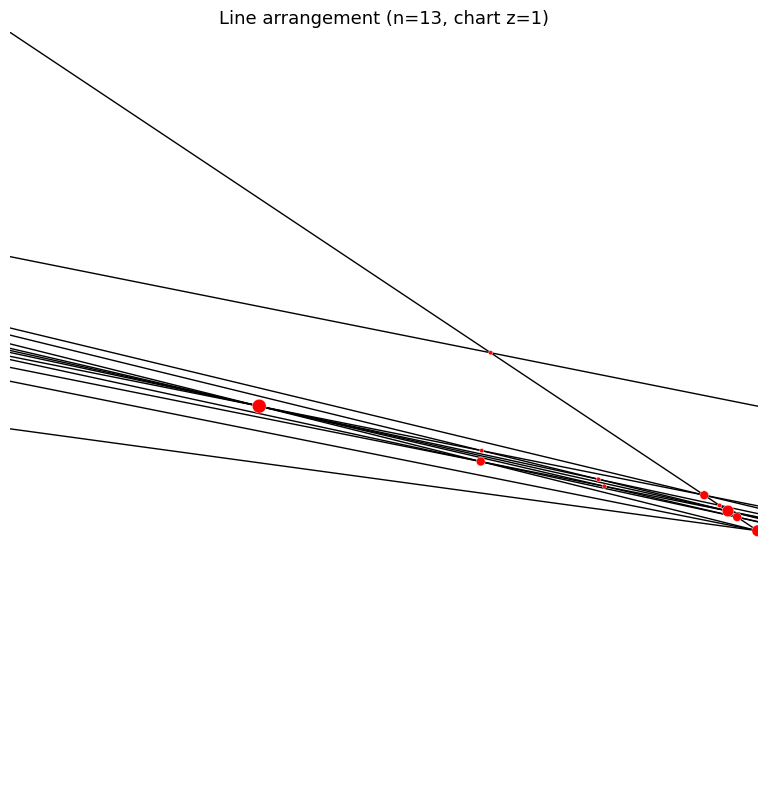

In [5]:
# {
#       "n": 13,
#       "exponents": [
#         1,
#         6,
#         6
#       ],
#       "b2": 48,
#       "max_mult": 5,
#       "mult_profile": [
#         5,
#         4,
#         4,
#         4,
#         4,
#         4,
#         4,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2
#       ],
#       "n_pts": 27,
#       "lines": [
#         "(1x+5y+-3z=0)",
#         "(1x+3/2y+-3/2z=0)",
#         "(1x+5y+2z=0)",
#         "(1x+4y+1z=0)",
#         "(1x+5y+1z=0)",
#         "(1x+137/33y+13/33z=0)",
#         "(1x+237/53y+1z=0)",
#         "(1x+249/61y+41/61z=0)",
#         "(1x+5y+13/9z=0)",
#         "(1x+337/73y+93/73z=0)",
#         "(1x+22/3y+13/3z=0)",
#         "(1x+349/81y+1z=0)",
#         "(1x+181/39y+1z=0)"
#       ],
#       "source": "train",
#       "target_exponents": [
#         5,
#         7
#       ],
#       "timestamp": "2026-03-30T15:01:42.645816+00:00"
#     }
lines = [
    "(1x+5y+-3z=0)",
    "(1x+3/2y+-3/2z=0)",
    "(1x+5y+2z=0)",
    "(1x+4y+1z=0)",
    "(1x+5y+1z=0)",
    "(1x+137/33y+13/33z=0)",
    "(1x+237/53y+1z=0)",
    "(1x+249/61y+41/61z=0)",
    "(1x+5y+13/9z=0)",
    "(1x+337/73y+93/73z=0)",
    "(1x+22/3y+13/3z=0)",
    "(1x+349/81y+1z=0)",
    "(1x+181/39y+1z=0)"
]

draw_arrangement(lines, xlim=(-3, 3), ylim=(-3, 3),
                 title=f'Line arrangement (n={len(lines)}, chart z=1)');

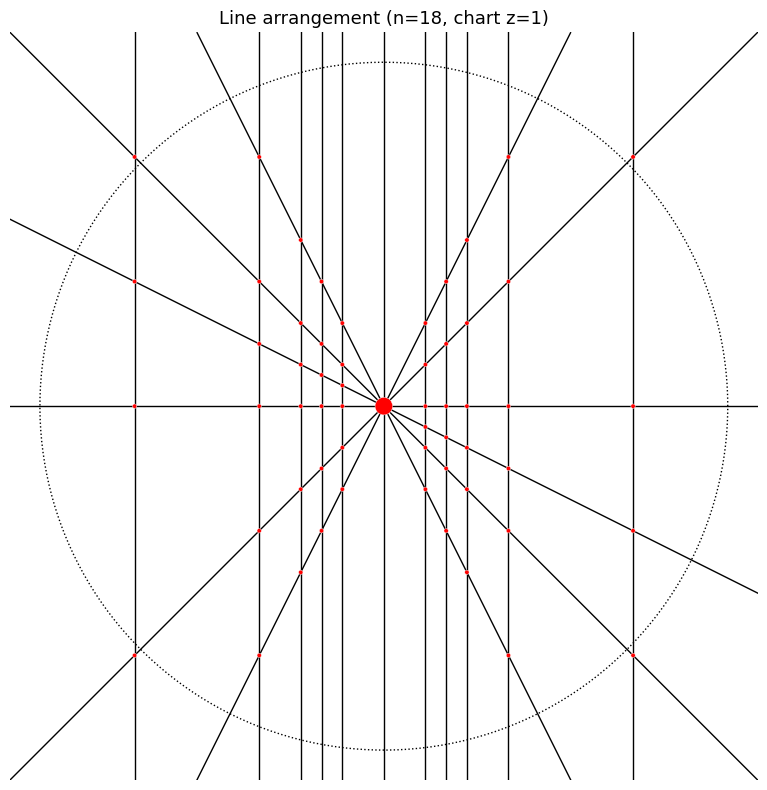

In [6]:
# {
#       "n": 18,
#       "exponents": [
#         1,
#         6,
#         11
#       ],
#       "b2": 83,
#       "max_mult": 12,
#       "mult_profile": [
#         12,
#         7,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2
#       ],
#       "n_pts": null,
#       "lines": [
#         "(1x+0y+0z=0)",
#         "(1x+1y+0z=0)",
#         "(1x+-1y+0z=0)",
#         "(0x+1y+0z=0)",
#         "(1x+1/2y+0z=0)",
#         "(1x+-1/2y+0z=0)",
#         "(1x+2y+0z=0)",
#         "(1x+0y+1z=0)",
#         "(1x+0y+-1z=0)",
#         "(0x+0y+1z=0)",
#         "(1x+0y+1/2z=0)",
#         "(1x+0y+-1/2z=0)",
#         "(1x+0y+2z=0)",
#         "(1x+0y+-2z=0)",
#         "(1x+0y+2/3z=0)",
#         "(1x+0y+1/3z=0)",
#         "(1x+0y+-1/3z=0)",
#         "(1x+0y+-2/3z=0)"
#       ],
#       "source": "construct-all-supersolvable",
#       "timestamp": "2026-04-18T10:39:29.330160+00:00"
#     },
lines = [
        "(1x+0y+0z=0)",
        "(1x+1y+0z=0)",
        "(1x+-1y+0z=0)",
        "(0x+1y+0z=0)",
        "(1x+1/2y+0z=0)",
        "(1x+-1/2y+0z=0)",
        "(1x+2y+0z=0)",
        "(1x+0y+1z=0)",
        "(1x+0y+-1z=0)",
        "(0x+0y+1z=0)",
        "(1x+0y+1/2z=0)",
        "(1x+0y+-1/2z=0)",
        "(1x+0y+2z=0)",
        "(1x+0y+-2z=0)",
        "(1x+0y+2/3z=0)",
        "(1x+0y+1/3z=0)",
        "(1x+0y+-1/3z=0)",
        "(1x+0y+-2/3z=0)"
      ]

draw_arrangement(lines, xlim=(-3, 3), ylim=(-3, 3),
                 title=f'Line arrangement (n={len(lines)}, chart z=1)');

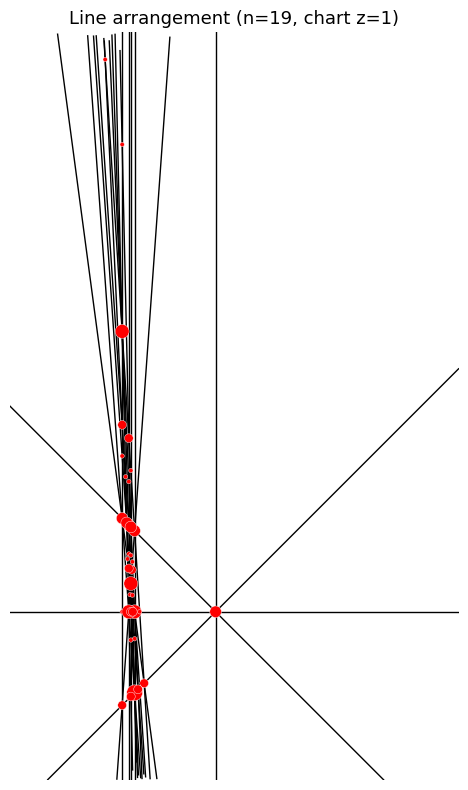

In [7]:
# {
#       "n": 19,
#       "exponents": [
#         1,
#         7,
#         11
#       ],
#       "b2": 95,
#       "max_mult": 6,
#       "mult_profile": [
#         6,
#         5,
#         5,
#         5,
#         5,
#         5,
#         5,
#         4,
#         4,
#         4,
#         4,
#         4,
#         4,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2
#       ],
#       "n_pts": null,
#       "lines": [
#         "(1x+-1y+-5/2z=0)",
#         "(1x+0y+4/3z=0)",
#         "(1x+0y+3/2z=0)",
#         "(1x+1y+3z=0)",
#         "(1x+1/14y+45/28z=0)",
#         "(1x+-1/14y+17/14z=0)",
#         "(1x+0y+79/56z=0)",
#         "(1x+1/29y+85/58z=0)",
#         "(1x+1/42y+31/21z=0)",
#         "(1x+0y+119/86z=0)",
#         "(1x+2/43y+65/43z=0)",
#         "(1x+1/44y+125/88z=0)",
#         "(1x+0y+1/4z=0)",
#         "(1x+1/16y+23/16z=0)",
#         "(1x+2/15y+17/10z=0)",
#         "(0x+1y+11/4z=0)",
#         "(1x+1/15y+91/60z=0)",
#         "(1x+2/45y+131/90z=0)",
#         "(1x+3/44y+17/11z=0)"
#       ],
#       "source": "extend",
#       "timestamp": "2026-04-17T07:30:10.894483+00:00"
#     },
lines = [
        "(1x+-1y+-5/2z=0)",
        "(1x+0y+4/3z=0)",
        "(1x+0y+3/2z=0)",
        "(1x+1y+3z=0)",
        "(1x+1/14y+45/28z=0)",
        "(1x+-1/14y+17/14z=0)",
        "(1x+0y+79/56z=0)",
        "(1x+1/29y+85/58z=0)",
        "(1x+1/42y+31/21z=0)",
        "(1x+0y+119/86z=0)",
        "(1x+2/43y+65/43z=0)",
        "(1x+1/44y+125/88z=0)",
        "(1x+0y+1/4z=0)",
        "(1x+1/16y+23/16z=0)",
        "(1x+2/15y+17/10z=0)",
        "(0x+1y+11/4z=0)",
        "(1x+1/15y+91/60z=0)",
        "(1x+2/45y+131/90z=0)",
        "(1x+3/44y+17/11z=0)"
      ]

draw_arrangement(lines, xlim=(-3, 3), ylim=(-5, 5),
                 title=f'Line arrangement (n={len(lines)}, chart z=1)');

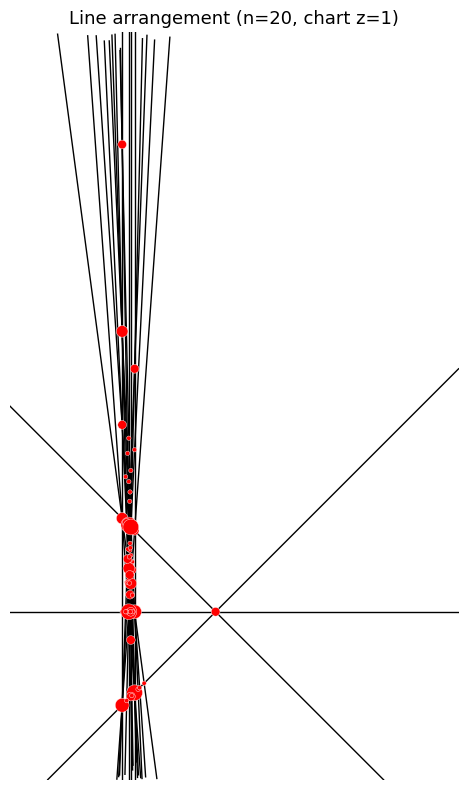

In [23]:
# {
#       "n": 20,
#       "exponents": [
#         1,
#         9,
#         10
#       ],
#       "b2": 109,
#       "max_mult": 6,
#       "mult_profile": [
#         6,
#         6,
#         6,
#         6,
#         5,
#         5,
#         4,
#         4,
#         4,
#         4,
#         4,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         3,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2,
#         2
#       ],
#       "n_pts": null,
#       "lines": [
#         "(1x+-1y+-5/2z=0)",
#         "(1x+0y+4/3z=0)",
#         "(1x+0y+3/2z=0)",
#         "(1x+1y+3z=0)",
#         "(1x+1/14y+45/28z=0)",
#         "(1x+-1/14y+17/14z=0)",
#         "(1x+0y+79/56z=0)",
#         "(1x+1/29y+85/58z=0)",
#         "(1x+1/42y+31/21z=0)",
#         "(1x+0y+119/86z=0)",
#         "(1x+2/43y+65/43z=0)",
#         "(1x+1/44y+125/88z=0)",
#         "(1x+-2/41y+107/82z=0)",
#         "(1x+2/15y+17/10z=0)",
#         "(1x+1/57y+82/57z=0)",
#         "(1x+-1/42y+113/84z=0)",
#         "(0x+1y+11/4z=0)",
#         "(1x+2/45y+131/90z=0)",
#         "(1x+-1/27y+73/54z=0)",
#         "(1x+1/15y+91/60z=0)"
#       ],
#       "source": "extend",
#       "timestamp": "2026-04-18T10:32:09.608662+00:00"
#     },

lines = [
        "(1x+-1y+-5/2z=0)",
        "(1x+0y+4/3z=0)",
        "(1x+0y+3/2z=0)",
        "(1x+1y+3z=0)",
        "(1x+1/14y+45/28z=0)",
        "(1x+-1/14y+17/14z=0)",
        "(1x+0y+79/56z=0)",
        "(1x+1/29y+85/58z=0)",
        "(1x+1/42y+31/21z=0)",
        "(1x+0y+119/86z=0)",
        "(1x+2/43y+65/43z=0)",
        "(1x+1/44y+125/88z=0)",
        "(1x+-2/41y+107/82z=0)",
        "(1x+2/15y+17/10z=0)",
        "(1x+1/57y+82/57z=0)",
        "(1x+-1/42y+113/84z=0)",
        "(0x+1y+11/4z=0)",
        "(1x+2/45y+131/90z=0)",
        "(1x+-1/27y+73/54z=0)",
        "(1x+1/15y+91/60z=0)"
      ]

draw_arrangement(lines, xlim=(-3, 3), ylim=(-5, 5),
                 title=f'Line arrangement (n={len(lines)}, chart z=1)');